                                                Лабораторна робота №4 “Класифікація”
                                                     Виконала Доля Анастасія КН-42-03
Мета: Ознайомитися з основами класифікації при інтелектуальному аналізі даних на прикладі реального історичного набору даних Titanic.
Навчитись будувати класифікатор на основі дерев рішень (Decision Tree), виконувати попередню обробку даних, навчати модель, оцінювати якість класифікації за допомогою стандартних метрик та інтерпретувати отримані результати.

In [21]:
import pandas as pd
import numpy as np

DATA_DIR = r'C:\Users\Anastasia\Downloads\titanic\train.csv'
df = pd.read_csv(DATA_DIR)

df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


Завантажили набір даних Titanic за допомогою бібліотеки pandas. Дані містять інформацію про пасажирів та факт їх виживання.

In [22]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    str    
 4   Sex          891 non-null    str    
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    str    
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    str    
 11  Embarked     889 non-null    str    
dtypes: float64(2), int64(5), str(5)
memory usage: 83.7 KB


За допомогою функції info() можемо бачити структуру набору даних, типи ознак та кількість ненульових значень. Виявлено наявність пропущених значень у змінних Age, Cabin та Embarked.

In [23]:
df.isnull().sum()

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64

In [24]:
df = df.drop(columns=["Cabin", "Name", "Ticket", "PassengerId"])
df["Age"].fillna(df["Age"].median(), inplace=True)
df["Embarked"].fillna(df["Embarked"].mode()[0], inplace=True)

C:\Users\Anastasia\AppData\Local\Temp\ipykernel_3124\201053950.py:2: ChainedAssignmentError: A value is being set on a copy of a DataFrame or Series through chained assignment using an inplace method.
Such inplace method never works to update the original DataFrame or Series, because the intermediate object on which we are setting values always behaves as a copy (due to Copy-on-Write).

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' instead, to perform the operation inplace on the original object, or try to avoid an inplace operation using 'df[col] = df[col].method(value)'.

See the documentation for a more detailed explanation: https://pandas.pydata.org/pandas-docs/stable/user_guide/copy_on_write.html
  df["Age"].fillna(df["Age"].median(), inplace=True)
C:\Users\Anastasia\AppData\Local\Temp\ipykernel_3124\201053950.py:3: ChainedAssignmentError: A value is being set on a copy of a DataFrame or Series through chained assi

0      S
1      C
2      S
3      S
4      S
      ..
886    S
887    S
888    S
889    C
890    Q
Name: Embarked, Length: 891, dtype: str

In [25]:
df["Sex"] = df["Sex"].map({"male": 0, "female": 1})

df = pd.get_dummies(df, columns=["Embarked"], drop_first=True)
df["Embarked_Q"] = df["Embarked_Q"].astype(int)
df["Embarked_S"] = df["Embarked_S"].astype(int)

In [26]:
df.isnull().sum()
df.head()

,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked_Q,Embarked_S
0,0,3,0,22.0,1,0,7.2500,0,1
1,1,1,1,38.0,1,0,71.2833,0,0
2,1,3,1,26.0,0,0,7.9250,0,1
3,1,1,1,35.0,1,0,53.1000,0,1
4,0,3,0,35.0,0,0,8.0500,0,1


Було виконано попередню обробку даних. Ознака Cabin була видалена через значну кількість пропущених значень. Пропущені значення у числовій ознаці Age заповнено медіаною, що дозволяє уникнути впливу викидів. Для категоріальної змінної Embarked пропуски заповнено модою — найбільш поширеним значенням.
Неінформативні або надлишкові ознаки, такі як Name, Ticket та PassengerId, були видалені. Категоріальна змінна Sex була перетворена у числовий формат (0 - чоловік, 1 - жінка). Змінна Embarked була закодована за допомогою one-hot encoding. Отримані булеві значення додатково приведено до числового типу.
Після обробки було перевірено відсутність пропущених значень. Усі ознаки були приведені до числового формату, що дозволяє використовувати їх для навчання моделі.

In [27]:
#2
from sklearn.model_selection import train_test_split

X = df.drop("Survived", axis=1)
y = df["Survived"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print(X_train.shape, X_test.shape)

(712, 8) (179, 8)


Дані було поділено на навчальну та тестову вибірки у співвідношенні 80% до 20% відповідно. Для збереження балансу класів використано параметр stratify.

In [28]:
from sklearn.tree import DecisionTreeClassifier

model = DecisionTreeClassifier(
    criterion="gini",
    max_depth=4,
    random_state=42
)

model.fit(X_train, y_train)

,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'gini'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",4
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... note:: The search for a split does not stop until at least one valid partition of the node samples is found, even if it requires to effectively inspect more than ``max_features`` features.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary ` for details.",42
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current no

Для класифікації було використано алгоритм дерева рішень. В якості критерію розбиття обрано індекс Джині (gini). Максимальна глибина дерева обмежена значенням 4 для запобігання перенавчанню моделі.

In [32]:
print("Глибина дерева:", model.get_depth())
print("Кількість вузлів:", model.tree_.node_count)
print("Кількість листів:", model.get_n_leaves())

Глибина дерева: 4
Кількість вузлів: 29
Кількість листів: 15


Тут бачимо структуру моделі. Глибина дерева становить 4, що відповідає встановленому обмеженню та запобігає перенавчанню. Загальна кількість вузлів дорівнює 29, що відображає кількість перевірок умов у дереві. Кількість листів становить 15 - це кінцеві вузли, в яких модель приймає рішення щодо класу.
Таким чином, дерево має помірну складність і здатне узагальнювати залежності в даних.

In [29]:
y_pred = model.predict(X_test)

from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report, confusion_matrix

print("Accuracy:", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred))
print("Recall:", recall_score(y_test, y_pred))
print("F1-score:", f1_score(y_test, y_pred))

print("\nClassification report:\n", classification_report(y_test, y_pred))
print("\nConfusion matrix:\n", confusion_matrix(y_test, y_pred))

Accuracy: 0.7877094972067039
Precision: 0.8444444444444444
Recall: 0.5507246376811594
F1-score: 0.6666666666666666

Classification report:
               precision    recall  f1-score   support

           0       0.77      0.94      0.84       110
           1       0.84      0.55      0.67        69

    accuracy                           0.79       179
   macro avg       0.81      0.74      0.76       179
weighted avg       0.80      0.79      0.78       179


Confusion matrix:
 [[103   7]
 [ 31  38]]


Після навчання моделі було виконано прогнозування для тестової вибірки та оцінено якість класифікації.
Отримано значення accuracy = 0.79, що означає, що модель правильно класифікує близько 79% об’єктів.
Значення precision = 0.84 свідчить про те, що більшість передбачених виживших пасажирів дійсно є такими.
Водночас recall = 0.55 є нижчим, що означає, що модель знаходить лише частину пасажирів, які фактично вижили.
F1-score = 0.67 показує збалансовану оцінку між precision та recall.
Іншими словами, модель має точність близько 79%. Високий precision означає, що передбачення виживших є досить точними, проте низький recall свідчить про те, що частина виживших пасажирів не була виявлена. Матриця помилок підтверджує, що модель краще класифікує клас "не вижив".

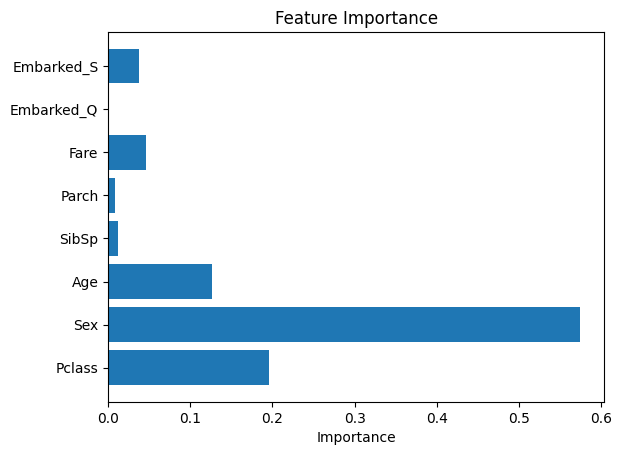

[('Sex', np.float64(0.5748911899198684)), ('Pclass', np.float64(0.19544230543779956)), ('Age', np.float64(0.12586730793597256)), ('Fare', np.float64(0.046255465690447736)), ('Embarked_S', np.float64(0.037107137249948956)), ('SibSp', np.float64(0.012079580069522035)), ('Parch', np.float64(0.008357013696440773)), ('Embarked_Q', np.float64(0.0))]


In [30]:
import matplotlib.pyplot as plt

importances = model.feature_importances_
features = X.columns

plt.barh(features, importances)
plt.xlabel("Importance")
plt.title("Feature Importance")
plt.show()

print(sorted(zip(features, importances), key=lambda x: x[1], reverse=True))

Було проаналізовано важливість ознак, отриману з моделі дерева рішень.
Найбільш значущою ознакою є стать пасажира (Sex), яка має найбільший вплив на ймовірність виживання. Також важливими є клас каюти (Pclass) та вік (Age), що свідчить про їх суттєву роль у процесі прийняття рішення моделлю.
Ознаки Fare та Embarked мають помірний вплив, тоді як SibSp та Parch практично не впливають на результат класифікації.
Таким чином, модель переважно використовує соціальні та демографічні характеристики пасажирів для прогнозування виживання.
Значення важливості ознак обчислюється на основі того, наскільки кожна ознака зменшує невизначеність (Gini impurity) при розбитті даних.

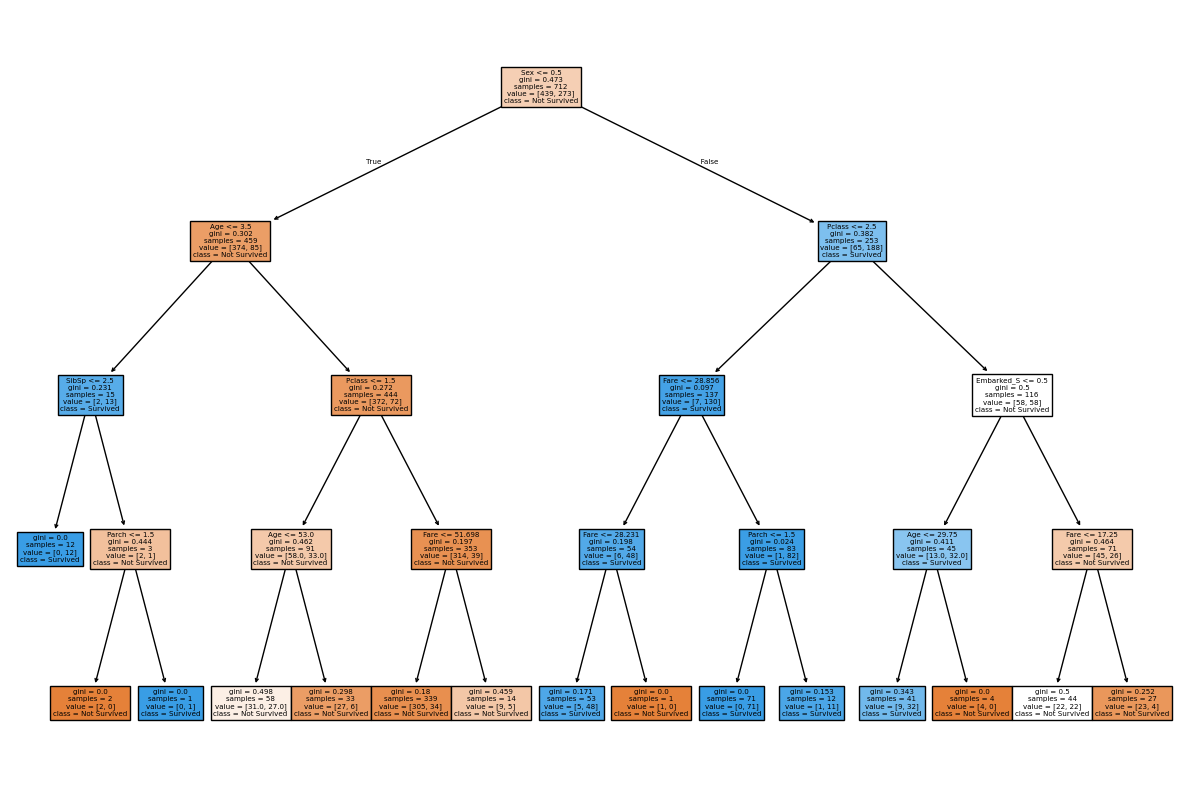

In [31]:
from sklearn.tree import plot_tree

plt.figure(figsize=(15,10))
plot_tree(model, feature_names=X.columns, class_names=["Not Survived", "Survived"], filled=True)
plt.show()

Було побудовано дерево рішень, яке дозволяє інтерпретувати модель у вигляді набору послідовних умов. Кожен внутрішній вузол дерева відповідає перевірці певної ознаки, а листові вузли містять кінцеве рішення щодо класу. Дерево будується шляхом послідовного розбиття даних за найбільш інформативними ознаками.

З отриманого дерева видно, що першим критерієм розбиття є ознака Sex, що підтверджує її найбільшу важливість. Далі модель використовує ознаки Age, Pclass та Fare для уточнення класифікації. Це означає, що рішення щодо виживання пасажира приймається на основі комбінації статі, віку та соціального статусу.

ROC-AUC: 0.8237812911725955


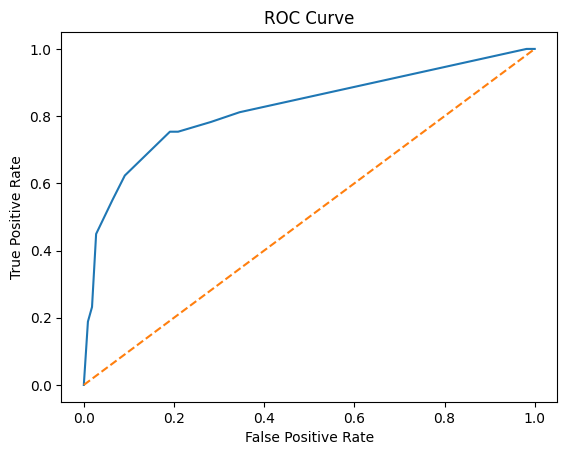

In [33]:
from sklearn.metrics import roc_auc_score, roc_curve
import matplotlib.pyplot as plt

y_prob = model.predict_proba(X_test)[:, 1]

auc = roc_auc_score(y_test, y_prob)
print("ROC-AUC:", auc)

fpr, tpr, _ = roc_curve(y_test, y_prob)

plt.plot(fpr, tpr)
plt.plot([0,1], [0,1], linestyle="--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.show()

Для додаткової оцінки якості моделі було побудовано ROC-криву та обчислено метрику ROC-AUC. ROC-крива відображає залежність між часткою правильно визначених позитивних випадків (True Positive Rate) та часткою хибнопозитивних спрацювань (False Positive Rate).
Отримане значення ROC-AUC ≈ 0.82 свідчить про хорошу здатність моделі розрізняти класи. Оскільки значення більше 0.5, модель працює значно краще за випадкову, а наближення до 1 означає високу якість класифікації. На графіку видно, що ROC-крива проходить значно вище діагоналі, яка відповідає випадковому класифікатору. Це означає, що модель здатна ефективно відокремлювати пасажирів, які вижили, від тих, хто не вижив.

Survived
0    549
1    342
Name: count, dtype: int64


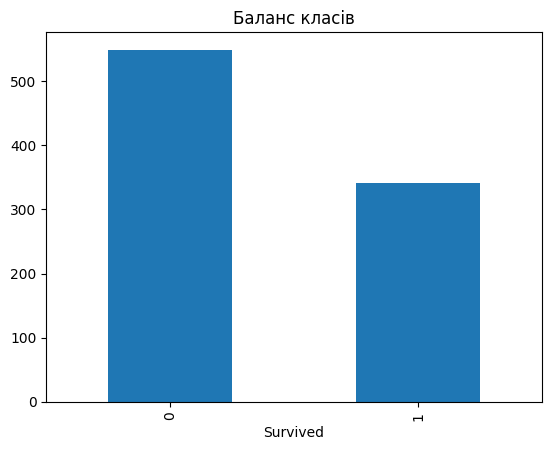

In [34]:
print(y.value_counts())

y.value_counts().plot(kind="bar")
plt.title("Баланс класів")
plt.show()

Було проаналізовано баланс класів у наборі даних. Встановлено, що кількість пасажирів, які не вижили (549), перевищує кількість тих, хто вижив (342).
Таким чином, дані є незбалансованими, що може впливати на якість роботи моделі. Наявність дисбалансу класів призводить до того, що модель краще навчається визначати домінуючий клас - пасажирів, які не вижили.
Це пояснює високе значення recall для класу 0 та нижче значення recall для класу 1.

Висновок: У роботі було досліджено задачу класифікації на прикладі набору даних Titanic. Було виконано попередню обробку даних, побудовано модель дерева рішень та оцінено її якість за допомогою основних метрик. Отримано точність близько 79%, при цьому модель добре визначає пасажирів, які не вижили, але гірше - тих, хто вижив. Найбільш значущою ознакою виявилася стать пасажира, що підтверджується як аналізом важливості ознак, так і структурою дерева рішень.
Також було встановлено, що дані є незбалансованими, що впливає на результати класифікації. Загалом модель показала задовільну якість та дозволяє інтерпретувати залежності між характеристиками пасажирів і їх виживанням.